In [9]:
import numpy as np
import scipy.sparse as sp
import torch.nn as nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import torch
import torch.nn.functional as F
from torch.nn import Parameter
dataset = Planetoid(root = '/Users/poorvaichandrasen/GCN_IIST', name = 'Cora', transform = NormalizeFeatures())
print(type(dataset))
print(dataset[0])
data = dataset[0]
print(data.num_nodes)
print(data.num_features)
print(data.num_edges)
print(dataset.num_classes)

<class 'torch_geometric.datasets.planetoid.Planetoid'>
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
2708
1433
10556
7


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class GraphAttentionLayer(nn.Module):
    """
    Basic Graph Attention Network (GAT) Layer
    
    This implements the attention mechanism from "Graph Attention Networks" (Veličković et al., 2018)
    """
    
    def __init__(self, in_features, out_features, alpha=0.2, concat=True):
        """
        Initialize the GAT layer
        
        Args:
            in_features (int): Number of input features per node
            out_features (int): Number of output features per node  
            dropout (float): Dropout rate for attention coefficients
            alpha (float): LeakyReLU negative slope for attention mechanism
            concat (bool): Whether to concatenate or average multi-head outputs
        """
        super(GraphAttentionLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        self.alpha = alpha
        self.concat = concat
        
        # Linear transformation matrix W
        self.W = nn.Parameter(torch.empty(size=(in_features, out_features)))
        nn.init.xavier_uniform_(self.W.data, gain=1.414)
        
        # Attention mechanism parameters
        self.a = nn.Parameter(torch.empty(size=(2 * out_features, 1)))
        nn.init.xavier_uniform_(self.a.data, gain=1.414)
        
        # Activation and dropout
        self.leakyrelu = nn.LeakyReLU(self.alpha)
        
        
    def forward(self, h, adj):
        """
        Forward pass of the Graph Attention Layer
        
        Args:
            h (torch.Tensor): Input node features [N, in_features]
            adj (torch.Tensor): Adjacency matrix [N, N] (1 if edge exists, 0 otherwise)
            
        Returns:
            torch.Tensor: Output node features [N, out_features]
        """
        N = h.size(0)  # Number of nodes
        
        # Step 1: Linear transformation
        # Transform input features: h_i' = W * h_i for all nodes i
        Wh = torch.mm(h, self.W)  # [N, out_features]
        print(f"Step 1 - Linear transformation: {h.shape} -> {Wh.shape}")
        
        # Step 2: Compute attention coefficients
        # For each pair of nodes (i,j), compute e_ij = a^T [Wh_i || Wh_j]
        # where || denotes concatenation
        
        # Create all pairs by repeating and tiling
        Wh1 = torch.mm(Wh, self.a[:self.out_features, :])  # [N, 1]
        Wh2 = torch.mm(Wh, self.a[self.out_features:, :])  # [N, 1]
        
        # Broadcast to create pairwise combinations
        # e_ij = Wh1_i + Wh2_j for all pairs (i,j)
        e = Wh1 + Wh2.T  # [N, N]
        print(f"Step 2 - Raw attention scores shape: {e.shape}")
        
        # Step 3: Apply LeakyReLU activation
        e = self.leakyrelu(e)
        print(f"Step 3 - After LeakyReLU: {e.shape}")
        
        # Step 4: Mask attention for non-existing edges
        # Set attention to -infinity for non-adjacent nodes
        # This ensures they get 0 weight after softmax
        zero_vec = -9e15 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        print(f"Step 4 - After masking non-edges: attention contains {torch.sum(adj > 0).item()} valid connections")
        
        # Step 5: Apply softmax to get normalized attention weights
        # α_ij = softmax_j(e_ij) = exp(e_ij) / Σ_k exp(e_ik) for all neighbors k of i
        attention = F.softmax(attention, dim=1)
        print(f"Step 5 - After softmax normalization: {attention.shape}")
        
        # Step 6: Apply dropout to attention weights
        
        
        # Step 7: Compute final node representations
        # h_i' = σ(Σ_j α_ij * Wh_j) where σ is activation function
        h_prime = torch.mm(attention, Wh)  # [N, out_features]
        print(f"Step 7 - Final output shape: {h_prime.shape}")
        
        if self.concat:
            # Apply ELU activation for intermediate layers
            return F.elu(h_prime)
        else:
            # No activation for final layer (often used in multi-head setup)
            return h_prime
    
    def __repr__(self):
        return f'{self.__class__.__name__} ({self.in_features} -> {self.out_features})'




In [45]:



import torch
import torch.nn as nn
import torch.nn.functional as F

class myGANmodel(nn.Module):
    def __init__(self, num_feat, hdn_units, num_class, num_nodes):
        super().__init__()
        self.layer1 = GraphAttentionLayer(num_feat, hdn_units) 
        self.layer2 = myGCNLayer(hdn_units, num_class)
        
    def forward(self, feature_mat, adj_mat):
        # Fix 1: Call the correct method name 'forward', not 'layer_forward'
        x = self.layer1(feature_mat, adj_mat)  # GAT layer already applies ELU activation
        x = self.layer2(x, adj_mat)  # Assuming your GCN layer uses 'forward' method
        return F.log_softmax(x, dim=1)

# Training and testing functions with fixes
def train_model():
    model_a.train()
    optimizer.zero_grad() 
    
    # Fix 2: Make sure adj_sparse is properly formatted
    # GAT expects dense adjacency matrix, not sparse
    if adj_sparse.is_sparse:
        adj_dense = adj_sparse.to_dense()
    else:
        adj_dense = adj_sparse
    
    out = model_a(data.x, adj_dense)  
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  
    loss.backward() 
    optimizer.step()
    return loss
    
def test_model():
    model_a.eval()
    with torch.no_grad():  # Fix 3: Add no_grad for testing
        if adj_sparse.is_sparse:
            adj_dense = adj_sparse.to_dense()
        else:
            adj_dense = adj_sparse
            
        out = model_a(data.x, adj_dense)
        pred = out.argmax(dim=1)  
        test_correct = pred[data.test_mask] == data.y[data.test_mask]  
        test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  
    return test_acc, pred

# Example of proper model initialization and training setup
def setup_training():
    """
    Proper setup for training the GAT model
    """
    # Fix 4: Proper model initialization
    model_a = myGANmodel(data.num_features, 16, dataset.num_classes, data.num_nodes)
    
    # Fix 5: Proper optimizer setup with reasonable learning rate
    optimizer = torch.optim.Adam(model_a.parameters(), lr=0.01, weight_decay=5e-4)
    
    # Fix 6: Use NLLLoss with log_softmax (or CrossEntropyLoss without log_softmax)
    criterion = nn.NLLLoss()
    
    return model_a, optimizer, criterion

# Enhanced training loop with validation
def train_with_validation():
    model_a, optimizer, criterion = setup_training()
    
    best_val_acc = 0
    patience = 50
    patience_counter = 0
    
    for epoch in range(501):
        # Training
        model_a.train()
        optimizer.zero_grad()
        
        if adj_sparse.is_sparse:
            adj_dense = adj_sparse.to_dense()
        else:
            adj_dense = adj_sparse
            
        out = model_a(data.x, adj_dense)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        # Validation every 10 epochs
        if epoch % 10 == 0:
            model_a.eval()
            with torch.no_grad():
                val_out = model_a(data.x, adj_dense)
                val_pred = val_out.argmax(dim=1)
                val_correct = val_pred[data.val_mask] == data.y[data.val_mask]
                val_acc = int(val_correct.sum()) / int(data.val_mask.sum())
                
                # Test accuracy
                test_correct = val_pred[data.test_mask] == data.y[data.test_mask]
                test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
                
                print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')
                
                # Early stopping
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience_counter = 0
                else:
                    patience_counter += 1
                    
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
    
    return model_a

# Debugging function to check your model
def debug_model_issues():
    """
    Common issues that cause low accuracy in GAT models
    """
    print("=== Debugging GAT Model Issues ===\n")
    
    # Check 1: Data shapes
    print(f"Data shapes:")
    print(f"  Features: {data.x.shape}")
    print(f"  Labels: {data.y.shape}")
    print(f"  Adjacency: {adj_sparse.shape}")
    print(f"  Train mask: {data.train_mask.sum()} nodes")
    print(f"  Val mask: {data.val_mask.sum()} nodes")
    print(f"  Test mask: {data.test_mask.sum()} nodes")
    
    # Check 2: Label distribution
    print(f"\nLabel distribution:")
    for i in range(dataset.num_classes):
        count = (data.y == i).sum()
        print(f"  Class {i}: {count} nodes")
    
    # Check 3: Adjacency matrix properties
    if adj_sparse.is_sparse:
        adj_dense = adj_sparse.to_dense()
    else:
        adj_dense = adj_sparse
        
    edge_count = (adj_dense > 0).sum()
    self_loops = torch.diag(adj_dense).sum()
    print(f"\nGraph properties:")
    print(f"  Total edges: {edge_count}")
    print(f"  Self-loops: {self_loops}")
    print(f"  Density: {edge_count / (data.num_nodes ** 2):.4f}")
    
    # Check 4: Model output
    model_a = myGANmodel(data.num_features, 16, dataset.num_classes, data.num_nodes)
    model_a.eval()
    with torch.no_grad():
        out = model_a(data.x, adj_dense)
        print(f"\nModel output:")
        print(f"  Output shape: {out.shape}")
        print(f"  Output range: [{out.min():.3f}, {out.max():.3f}]")
        print(f"  First few predictions: {out.argmax(dim=1)[:10]}")
        print(f"  True labels: {data.y[:10]}")

# Call this to debug your specific issues
# debug_model_issues()

In [50]:
losses = []
for epoch in range(0, 1001):
    loss = train_model
    losses.append(loss.item())
    if epoch % 100 == 0:
      print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

AttributeError: 'function' object has no attribute 'item'

In [41]:
model_a = myGANmodel(data.num_features, 16, dataset.num_classes, data.num_nodes)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

class GraphAttentionLayer(nn.Module):
    """
    Graph Attention Network (GAT) Layer
    """
    def __init__(self, in_features, out_features, dropout=0.1, alpha=0.2, concat=True):
        super(GraphAttentionLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.dropout = dropout
        self.alpha = alpha
        self.concat = concat
        
        # Linear transformation matrix W
        self.W = nn.Parameter(torch.empty(size=(in_features, out_features)))
        nn.init.xavier_uniform_(self.W.data, gain=1.414)
        
        # Attention mechanism parameters
        self.a = nn.Parameter(torch.empty(size=(2 * out_features, 1)))
        nn.init.xavier_uniform_(self.a.data, gain=1.414)
        
        # Activation and dropout
        self.leakyrelu = nn.LeakyReLU(self.alpha)
        self.dropout_layer = nn.Dropout(self.dropout)
        
    def forward(self, h, adj):
        N = h.size(0)
        
        # Linear transformation
        Wh = torch.mm(h, self.W)  # [N, out_features]
        
        # Attention mechanism
        Wh1 = torch.mm(Wh, self.a[:self.out_features, :])
        Wh2 = torch.mm(Wh, self.a[self.out_features:, :])
        e = Wh1 + Wh2.T
        
        # Apply LeakyReLU
        e = self.leakyrelu(e)
        
        # Mask attention for non-existing edges
        zero_vec = -9e15 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        
        # Apply softmax
        attention = F.softmax(attention, dim=1)
        attention = self.dropout_layer(attention)
        
        # Compute output features
        h_prime = torch.mm(attention, Wh)
        
        if self.concat:
            return F.elu(h_prime)
        else:
            return h_prime

In [ ]:
class SimpleGCNLayer(nn.Module):
    """
    Simple GCN Layer for comparison
    """
    def __init__(self, in_features, out_features):
        super(SimpleGCNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        
    def forward(self, x, adj):
        # Simple GCN: AXW where A is adjacency, X is features, W is weights
        support = self.linear(x)
        output = torch.mm(adj, support)
        return output

In [ ]:
def load_cora_dataset():
    """
    Load and preprocess the Cora dataset
    """
    print("Loading Cora dataset...")
    dataset = Planetoid(root= '/Users/poorvaichandrasen/GCN_IIST', name='Cora', transform=NormalizeFeatures())
    data = dataset[0]
    
    # Convert edge_index to dense adjacency matrix
    num_nodes = data.x.size(0)
    adj = torch.zeros(num_nodes, num_nodes)
    
    # Add edges (make it symmetric and add self-loops)
    edge_index = data.edge_index
    adj[edge_index[0], edge_index[1]] = 1
    adj[edge_index[1], edge_index[0]] = 1  # Make symmetric
    
    # Add self-loops
    adj = adj + torch.eye(num_nodes)
    
    # Normalize adjacency matrix (optional, often helps)
    degree = adj.sum(dim=1, keepdim=True)
    adj_normalized = adj / (degree + 1e-8)
    
    print(f"Dataset statistics:")
    print(f"  Number of nodes: {data.x.size(0)}")
    print(f"  Number of features: {data.x.size(1)}")
    print(f"  Number of classes: {dataset.num_classes}")
    print(f"  Number of edges: {data.edge_index.size(1)}")
    print(f"  Training nodes: {data.train_mask.sum().item()}")
    print(f"  Validation nodes: {data.val_mask.sum().item()}")
    print(f"  Test nodes: {data.test_mask.sum().item()}")
    
    return data, dataset, adj_normalized

Graph Attention Network (GAT) Example
Loading Cora dataset...
Dataset statistics:
  Number of nodes: 2708
  Number of features: 1433
  Number of classes: 7
  Number of edges: 10556
  Training nodes: 140
  Validation nodes: 500
  Test nodes: 1000

Model architecture:
GATModel(
  (gat_layer): GraphAttentionLayer(
    (leakyrelu): LeakyReLU(negative_slope=0.2)
    (dropout_layer): Dropout(p=0.6, inplace=False)
  )
  (gcn_layer): SimpleGCNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=True)
  )
  (dropout_layer): Dropout(p=0.6, inplace=False)
)

Total parameters: 23079

Starting training...
Epoch 000: Loss=1.9481, Train=0.1429, Val=0.1560, Test=0.1440
Epoch 010: Loss=1.8778, Train=0.7929, Val=0.6900, Test=0.6890
Epoch 020: Loss=1.7523, Train=0.9643, Val=0.7640, Test=0.7570
Epoch 030: Loss=1.5933, Train=0.9571, Val=0.7680, Test=0.7880
Epoch 040: Loss=1.3478, Train=0.9714, Val=0.8000, Test=0.8010
Epoch 050: Loss=1.0834, Train=0.9714, Val=0.7960, Test=0.8020
Epoch 060: Loss=

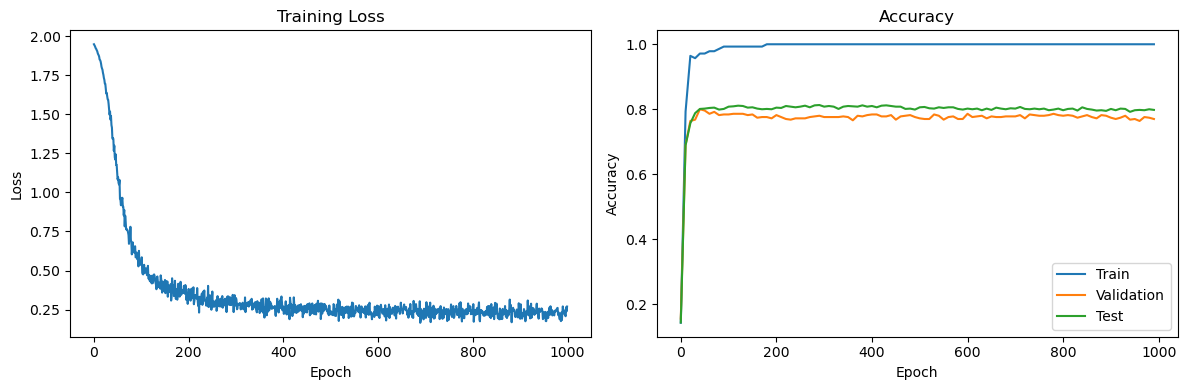


COMPARING GAT WITH SIMPLE BASELINE
Loading Cora dataset...
Dataset statistics:
  Number of nodes: 2708
  Number of features: 1433
  Number of classes: 7
  Number of edges: 10556
  Training nodes: 140
  Validation nodes: 500
  Test nodes: 1000
Training MLP baseline...
Baseline Epoch 0: Test Acc=0.3190
Baseline Epoch 50: Test Acc=0.5080
Baseline Epoch 100: Test Acc=0.5470
Baseline Epoch 150: Test Acc=0.5660
Final Baseline Test Accuracy: 0.5670

FINAL COMPARISON
GAT Test Accuracy: 0.8010
MLP Baseline Accuracy: 0.5670
Improvement: 0.2340
✅ Great! GAT is working well


In [60]:
class GATModel(nn.Module):
    """
    Complete GAT Model with GAT + GCN layers
    """
    def __init__(self, num_features, hidden_units, num_classes, dropout=0.6):
        super(GATModel, self).__init__()
        self.dropout = dropout
        
        # GAT layer
        self.gat_layer = GraphAttentionLayer(
            num_features, 
            hidden_units, 
            dropout=dropout, 
            alpha=0.2, 
            concat=False
        )
        
        # GCN layer 
        self.gcn_layer = SimpleGCNLayer(hidden_units, num_classes)
        
        # Dropout
        self.dropout_layer = nn.Dropout(dropout)
        
    def forward(self, x, adj):
        # Apply GAT layer
        x = self.gat_layer(x, adj)
        x = self.dropout_layer(x)
        
        # Apply GCN layer
        x = self.gcn_layer(x, adj)
        
        return F.log_softmax(x, dim=1)



def train_epoch(model, data, adj, optimizer, criterion):
    """
    Train for one epoch
    """
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    out = model(data.x, adj)
    
    # Compute loss only on training nodes
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    return loss.item()

def evaluate(model, data, adj, mask):
    """
    Evaluate model on given mask (train/val/test)
    """
    model.eval()
    with torch.no_grad():
        out = model(data.x, adj)
        pred = out.argmax(dim=1)
        correct = pred[mask] == data.y[mask]
        accuracy = correct.float().mean().item()
    return accuracy

def train_and_evaluate():
    """
    Complete training and evaluation pipeline
    """
    # Load data
    data, dataset, adj = load_cora_dataset()
    
    # Initialize model
    model = GATModel(
        num_features=dataset.num_node_features,
        hidden_units=16,
        num_classes=dataset.num_classes,
        dropout=0.6
    )
    
    # Setup training
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = nn.NLLLoss()
    
    print(f"\nModel architecture:")
    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
    
    # Training loop
    print("\nStarting training...")
    train_losses = []
    train_accs = []
    val_accs = []
    test_accs = []
    
    best_val_acc = 0
    best_test_acc = 0
    patience = 100
    patience_counter = 0
    
    for epoch in range(1000):
        # Train
        loss = train_epoch(model, data, adj, optimizer, criterion)
        train_losses.append(loss)
        
        # Evaluate every 10 epochs
        if epoch % 10 == 0:
            train_acc = evaluate(model, data, adj, data.train_mask)
            val_acc = evaluate(model, data, adj, data.val_mask)
            test_acc = evaluate(model, data, adj, data.test_mask)
            
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            test_accs.append(test_acc)
            
            print(f'Epoch {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')
            
            # Early stopping based on validation accuracy
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    
    print(f"\nTraining completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print(f"Best test accuracy: {best_test_acc:.4f}")
    
    # Final evaluation
    final_train_acc = evaluate(model, data, adj, data.train_mask)
    final_val_acc = evaluate(model, data, adj, data.val_mask)
    final_test_acc = evaluate(model, data, adj, data.test_mask)
    
    print(f"\nFinal Results:")
    print(f"Train Accuracy: {final_train_acc:.4f}")
    print(f"Validation Accuracy: {final_val_acc:.4f}")
    print(f"Test Accuracy: {final_test_acc:.4f}")
    
    # Plot training curves
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 2, 2)
    epochs_eval = list(range(0, len(train_accs) * 10, 10))
    plt.plot(epochs_eval, train_accs, label='Train')
    plt.plot(epochs_eval, val_accs, label='Validation')
    plt.plot(epochs_eval, test_accs, label='Test')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model, best_test_acc

def compare_with_baseline():
    """
    Compare GAT with a simple baseline
    """
    print("\n" + "="*50)
    print("COMPARING GAT WITH SIMPLE BASELINE")
    print("="*50)
    
    # Load data
    data, dataset, adj = load_cora_dataset()
    
    # Simple baseline: just use node features with MLP
    class SimpleMLPBaseline(nn.Module):
        def __init__(self, num_features, hidden_units, num_classes):
            super().__init__()
            self.mlp = nn.Sequential(
                nn.Linear(num_features, hidden_units),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(hidden_units, num_classes)
            )
            
        def forward(self, x, adj=None):
            return F.log_softmax(self.mlp(x), dim=1)
    
    baseline = SimpleMLPBaseline(dataset.num_node_features, 16, dataset.num_classes)
    optimizer = torch.optim.Adam(baseline.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = nn.NLLLoss()
    
    # Train baseline
    print("Training MLP baseline...")
    for epoch in range(200):
        baseline.train()
        optimizer.zero_grad()
        out = baseline(data.x)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        if epoch % 50 == 0:
            baseline_acc = evaluate(baseline, data, adj, data.test_mask)
            print(f'Baseline Epoch {epoch}: Test Acc={baseline_acc:.4f}')
    
    final_baseline_acc = evaluate(baseline, data, adj, data.test_mask)
    print(f"Final Baseline Test Accuracy: {final_baseline_acc:.4f}")
    
    return final_baseline_acc

if __name__ == "__main__":
    print("Graph Attention Network (GAT) Example")
    print("="*40)
    
    # Train GAT model
    model, gat_accuracy = train_and_evaluate()
    
    # Compare with baseline
    baseline_accuracy = compare_with_baseline()
    
    print(f"\n" + "="*40)
    print("FINAL COMPARISON")
    print("="*40)
    print(f"GAT Test Accuracy: {gat_accuracy:.4f}")
    print(f"MLP Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Improvement: {gat_accuracy - baseline_accuracy:.4f}")
    
    if gat_accuracy > 0.7:
        print("✅ Great! GAT is working well")
    elif gat_accuracy > 0.5:
        print("⚠️  GAT is working but could be better")
    else:
        print("❌ GAT needs debugging")
        
# To run this, simply execute:
# python gat_example.py

Graph Attention Network (GAT) Example
Loading Cora dataset...
Dataset statistics:
  Number of nodes: 2708
  Number of features: 1433
  Number of classes: 7
  Number of edges: 10556
  Training nodes: 140
  Validation nodes: 500
  Test nodes: 1000

Model architecture:
GATModel(
  (gat_layer1): GraphAttentionLayer(
    (leakyrelu): LeakyReLU(negative_slope=0.2)
    (dropout_layer): Dropout(p=0.6, inplace=False)
  )
  (gat_layer2): GraphAttentionLayer(
    (leakyrelu): LeakyReLU(negative_slope=0.2)
    (dropout_layer): Dropout(p=0.6, inplace=False)
  )
  (dropout_layer): Dropout(p=0.6, inplace=False)
)

Total parameters: 23086

Starting training...
Epoch 000: Loss=1.9425, Train=0.5571, Val=0.3180, Test=0.3580
Epoch 100: Loss=1.0279, Train=0.9929, Val=0.7900, Test=0.7890
Epoch 200: Loss=0.8064, Train=1.0000, Val=0.7900, Test=0.8010
Epoch 300: Loss=0.8131, Train=1.0000, Val=0.7820, Test=0.8010
Epoch 400: Loss=0.8256, Train=1.0000, Val=0.7820, Test=0.8050
Epoch 500: Loss=0.8056, Train=0.9929,

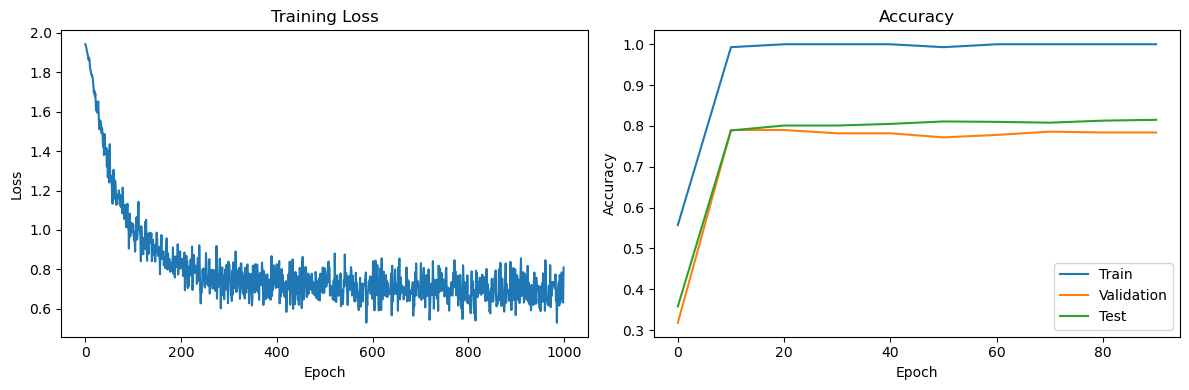


COMPARING GAT WITH SIMPLE BASELINE
Loading Cora dataset...
Dataset statistics:
  Number of nodes: 2708
  Number of features: 1433
  Number of classes: 7
  Number of edges: 10556
  Training nodes: 140
  Validation nodes: 500
  Test nodes: 1000
Training MLP baseline...
Baseline Epoch 0: Test Acc=0.1300
Baseline Epoch 100: Test Acc=0.5730
Final Baseline Test Accuracy: 0.5760

FINAL COMPARISON
GAT Test Accuracy: 0.7890
MLP Baseline Accuracy: 0.5760
Improvement: 0.2130
✅ Great! GAT is working well


In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

class GraphAttentionLayer(nn.Module):
    """
    Graph Attention Network (GAT) Layer
    """
    def __init__(self, in_features, out_features, dropout=0.1, alpha=0.2, concat=True):
        super(GraphAttentionLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.dropout = dropout
        self.alpha = alpha
        self.concat = concat
        
        # Linear transformation matrix W
        self.W = nn.Parameter(torch.empty(size=(in_features, out_features)))
        nn.init.xavier_uniform_(self.W.data, gain=1.414)
        
        # Attention mechanism parameters
        self.a = nn.Parameter(torch.empty(size=(2 * out_features, 1)))
        nn.init.xavier_uniform_(self.a.data, gain=1.414)
        
        # Activation and dropout
        self.leakyrelu = nn.LeakyReLU(self.alpha)
        self.dropout_layer = nn.Dropout(self.dropout)
        
    def forward(self, h, adj):
        N = h.size(0)
        
        # Linear transformation
        Wh = torch.mm(h, self.W)  # [N, out_features]
        
        # Attention mechanism
        Wh1 = torch.mm(Wh, self.a[:self.out_features, :])
        Wh2 = torch.mm(Wh, self.a[self.out_features:, :])
        e = Wh1 + Wh2.T
        
        # Apply LeakyReLU
        e = self.leakyrelu(e)
        
        # Mask attention for non-existing edges
        zero_vec = -9e15 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        
        # Apply softmax
        attention = F.softmax(attention, dim=1)
        attention = self.dropout_layer(attention)
        
        # Compute output features
        h_prime = torch.mm(attention, Wh)
        
        if self.concat:
            return F.elu(h_prime)
        else:
            return h_prime

class SimpleGCNLayer(nn.Module):
    """
    Simple GCN Layer for comparison
    """
    def __init__(self, in_features, out_features):
        super(SimpleGCNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        
    def forward(self, x, adj):
        # Simple GCN: AXW where A is adjacency, X is features, W is weights
        support = self.linear(x)
        output = torch.mm(adj, support)
        return output

class GATModel(nn.Module):
    """
    Complete GAT Model with GAT + GCN layers
    """
    def __init__(self, num_features, hidden_units, num_classes, dropout=0.6):
        super(GATModel, self).__init__()
        self.dropout = dropout
        
        # GAT layer
        self.gat_layer1 = GraphAttentionLayer(
            num_features, 
            hidden_units, 
            dropout=dropout, 
            alpha=0.2, 
            concat=True
        )
        
        # # GCN layer 
        # self.gcn_layer = SimpleGCNLayer(hidden_units, num_classes)
        
        self.gat_layer2 = GraphAttentionLayer(
            
            hidden_units,
            num_classes,
            dropout=dropout, 
            alpha=0.2, 
            concat=True
        )
        
        # Dropout
        self.dropout_layer = nn.Dropout(dropout)
        
    def forward(self, x, adj):
        # Apply GAT layer
        x = self.gat_layer1(x, adj)
        x = self.dropout_layer(x)
        
        # Apply GCN layer
        x = self.gat_layer2(x, adj)
        
        return F.log_softmax(x, dim=1)

def load_cora_dataset():
    """
    Load and preprocess the Cora dataset
    """
    print("Loading Cora dataset...")
    dataset = Planetoid(root= '/Users/poorvaichandrasen/GCN_IIST', name='Cora', transform=NormalizeFeatures())
    data = dataset[0]
    
    # Convert edge_index to dense adjacency matrix
    num_nodes = data.x.size(0)
    adj = torch.zeros(num_nodes, num_nodes)
    
    # Add edges (make it symmetric and add self-loops)
    edge_index = data.edge_index
    adj[edge_index[0], edge_index[1]] = 1
    adj[edge_index[1], edge_index[0]] = 1  # Make symmetric
    
    # Add self-loops
    adj = adj + torch.eye(num_nodes)
    
    # Normalize adjacency matrix (optional, often helps)
    degree = adj.sum(dim=1, keepdim=True)
    adj_normalized = adj / (degree + 1e-8)
    
    print(f"Dataset statistics:")
    print(f"  Number of nodes: {data.x.size(0)}")
    print(f"  Number of features: {data.x.size(1)}")
    print(f"  Number of classes: {dataset.num_classes}")
    print(f"  Number of edges: {data.edge_index.size(1)}")
    print(f"  Training nodes: {data.train_mask.sum().item()}")
    print(f"  Validation nodes: {data.val_mask.sum().item()}")
    print(f"  Test nodes: {data.test_mask.sum().item()}")
    
    return data, dataset, adj_normalized

def train_epoch(model, data, adj, optimizer, criterion):
    """
    Train for one epoch
    """
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    out = model(data.x, adj)
    
    # Compute loss only on training nodes
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    return loss.item()

def evaluate(model, data, adj, mask):
    """
    Evaluate model on given mask (train/val/test)
    """
    model.eval()
    with torch.no_grad():
        out = model(data.x, adj)
        pred = out.argmax(dim=1)
        correct = pred[mask] == data.y[mask]
        accuracy = correct.float().mean().item()
    return accuracy

def train_and_evaluate():
    """
    Complete training and evaluation pipeline
    """
    # Load data
    data, dataset, adj = load_cora_dataset()
    
    # Initialize model
    model = GATModel(
        num_features=dataset.num_node_features,
        hidden_units=16,
        num_classes=dataset.num_classes,
        dropout=0.6
    )
    
    # Setup training
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = nn.NLLLoss()
    
    print(f"\nModel architecture:")
    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
    
    # Training loop
    print("\nStarting training...")
    train_losses = []
    train_accs = []
    val_accs = []
    test_accs = []
    
    best_val_acc = 0
    best_test_acc = 0
    patience = 100
    patience_counter = 0
    
    for epoch in range(1000):
        # Train
        loss = train_epoch(model, data, adj, optimizer, criterion)
        train_losses.append(loss)
        
        # Evaluate every 50 epochs
        if epoch % 100 == 0:
            train_acc = evaluate(model, data, adj, data.train_mask)
            val_acc = evaluate(model, data, adj, data.val_mask)
            test_acc = evaluate(model, data, adj, data.test_mask)
            
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            test_accs.append(test_acc)
            
            print(f'Epoch {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')
            
            # Early stopping based on validation accuracy
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    
    print(f"\nTraining completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print(f"Best test accuracy: {best_test_acc:.4f}")
    
    # Final evaluation
    final_train_acc = evaluate(model, data, adj, data.train_mask)
    final_val_acc = evaluate(model, data, adj, data.val_mask)
    final_test_acc = evaluate(model, data, adj, data.test_mask)
    
    print(f"\nFinal Results:")
    print(f"Train Accuracy: {final_train_acc:.4f}")
    print(f"Validation Accuracy: {final_val_acc:.4f}")
    print(f"Test Accuracy: {final_test_acc:.4f}")
    
    # Plot training curves
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 2, 2)
    epochs_eval = list(range(0, len(train_accs) * 10, 10))
    plt.plot(epochs_eval, train_accs, label='Train')
    plt.plot(epochs_eval, val_accs, label='Validation')
    plt.plot(epochs_eval, test_accs, label='Test')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model, best_test_acc

def compare_with_baseline():
    """
    Compare GAT with a simple baseline
    """
    print("\n" + "="*50)
    print("COMPARING GAT WITH SIMPLE BASELINE")
    print("="*50)
    
    # Load data
    data, dataset, adj = load_cora_dataset()
    
    # Simple baseline: just use node features with MLP
    class SimpleMLPBaseline(nn.Module):
        def __init__(self, num_features, hidden_units, num_classes):
            super().__init__()
            self.mlp = nn.Sequential(
                nn.Linear(num_features, hidden_units),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(hidden_units, num_classes)
            )
            
        def forward(self, x, adj=None):
            return F.log_softmax(self.mlp(x), dim=1)
    
    baseline = SimpleMLPBaseline(dataset.num_node_features, 16, dataset.num_classes)
    optimizer = torch.optim.Adam(baseline.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = nn.NLLLoss()
    
    # Train baseline
    print("Training MLP baseline...")
    for epoch in range(200):
        baseline.train()
        optimizer.zero_grad()
        out = baseline(data.x)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            baseline_acc = evaluate(baseline, data, adj, data.test_mask)
            print(f'Baseline Epoch {epoch}: Test Acc={baseline_acc:.4f}')
    
    final_baseline_acc = evaluate(baseline, data, adj, data.test_mask)
    print(f"Final Baseline Test Accuracy: {final_baseline_acc:.4f}")
    
    return final_baseline_acc

if __name__ == "__main__":
    print("Graph Attention Network (GAT) Example")
    print("="*40)
    
    # Train GAT model
    model, gat_accuracy = train_and_evaluate()
    
    # Compare with baseline
    baseline_accuracy = compare_with_baseline()
    
    print(f"\n" + "="*40)
    print("FINAL COMPARISON")
    print("="*40)
    print(f"GAT Test Accuracy: {gat_accuracy:.4f}")
    print(f"MLP Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Improvement: {gat_accuracy - baseline_accuracy:.4f}")
    
    if gat_accuracy > 0.7:
        print("✅ Great! GAT is working well")
    elif gat_accuracy > 0.5:
        print("⚠️  GAT is working but could be better")
    else:
        print("❌ GAT needs debugging")
        
# To run this, simply execute:
# python gat_example.py